# **Model Training**

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import sys
sys.path.append("../src")
import importlib, preprocess
importlib.reload(preprocess)
import model as model_mod
importlib.reload(model_mod)
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, brier_score_loss
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
import joblib
import tempfile
import os
from pathlib import Path
from xgboost import XGBClassifier
import explain as explain_mod

c:\Users\Nitro\anaconda3\envs\catopt\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading the raw dataset

df = pd.read_csv("../data/raw/train.csv")

In [3]:
# Re-applying dataset scoping from EDA notebook

df_cats = df[df["Type"] == 2].copy()
df_cats_single = df_cats[df_cats["Quantity"] == 1].copy()
df_cats_single["adopted_fast"] = (df_cats_single["AdoptionSpeed"] <= 2).astype(int)

In [4]:
# Preprocessing the dataset

features = preprocess.preprocess(df_cats_single)
target = df_cats_single[preprocess.TARGET]

In [5]:
# Splitting train and test data

X_train, X_test, y_train, y_test = model_mod.split_data(features, target)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train Balance: {y_train.mean():.3f}, Test Balance: {y_test.mean():.3f}")

Train: (3954, 13), Test: (989, 13)
Train Balance: 0.566, Test Balance: 0.565


In [6]:
# Training the baseline model

clf = model_mod.train_model(X_train, y_train)

In [7]:
# Evaluating the model briefly

proba = clf.predict_proba(X_test)[:, 1]
preds = (proba >= 0.5).astype(int)
print(f"\nBaseline Test AUC: {roc_auc_score(y_test, proba):.4f}")
print(f"Baseline Test F1 (at threshold 0.5): {f1_score(y_test, preds):.4f}")


Baseline Test AUC: 0.6921
Baseline Test F1 (at threshold 0.5): 0.7256


In [8]:
# Setting up MLflow

mlflow.set_tracking_uri("sqlite:///../mlruns.db")
mlflow.set_experiment("cat-profile-optimizer")
print(f"MLflow {mlflow.__version__} | tracking -> sqlite mlruns.db")

MLflow 3.14.0 | tracking -> sqlite mlruns.db


In [9]:
# Creating a function to run the MLflow experiment

def run_experiment(params: dict | None = None, run_name: str = "baseline"):
    """Train + evaluate one model, logged to MLflow. Returns the fitted model."""

    with mlflow.start_run(run_name=run_name):
        effective_params = {**model_mod.DEFAULT_PARAMS, **(params or {})}
        mlflow.log_params(effective_params)

        clf = model_mod.train_model(X_train, y_train, params)

        proba = clf.predict_proba(X_test)[:, 1]
        preds = (proba >= 0.5).astype(int)
        metrics = {
            "test_auc": roc_auc_score(y_test, proba),
            "test_pr_auc": average_precision_score(y_test, proba),
            "test_f1": f1_score(y_test, preds),
        }
        mlflow.log_metrics(metrics)
        
        with tempfile.TemporaryDirectory() as tmp:
            model_file = os.path.join(tmp, "model.joblib")
            joblib.dump(clf, model_file)
            mlflow.log_artifact(model_file, artifact_path="model")

        print(f"[{run_name}] " + " | ".join(f"{k}={v:.4f}" for k, v in metrics.items()))
        return clf

In [10]:
# Re-running the baseline model training (now tracked)

clf = run_experiment(run_name="baseline")

[baseline] test_auc=0.6921 | test_pr_auc=0.7204 | test_f1=0.7256


In [11]:
# Running variations of the baseline model

run_experiment({"max_depth": 4}, run_name="shallower_d4")
run_experiment({"max_depth": 7}, run_name="deeper_d7")
run_experiment({"learning_rate": 0.1, "n_estimators": 200}, run_name="faster_lr")
run_experiment({"learning_rate": 0.03, "n_estimators": 500}, run_name="slower_lr")
run_experiment({"subsample": 0.6, "colsample_bytree": 0.6}, run_name="more_regularized")
run_experiment({"max_depth": 6, "learning_rate": 0.03, "n_estimators": 500,
                "subsample": 0.7, "colsample_bytree": 0.7}, run_name="combo")

[shallower_d4] test_auc=0.6921 | test_pr_auc=0.7204 | test_f1=0.7256
[deeper_d7] test_auc=0.6911 | test_pr_auc=0.7231 | test_f1=0.7057
[faster_lr] test_auc=0.6846 | test_pr_auc=0.7203 | test_f1=0.7168
[slower_lr] test_auc=0.6883 | test_pr_auc=0.7199 | test_f1=0.7265
[more_regularized] test_auc=0.6926 | test_pr_auc=0.7273 | test_f1=0.7189
[combo] test_auc=0.6893 | test_pr_auc=0.7201 | test_f1=0.7219


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_

The variations of the baseline model above do not have major differences with the baseline itself. ```deeper_d7``` will be the best pick as its AUC ties with the baseline and it has the highest F1 score. Furthermore, it is the simplest model with the ```max_depth``` being 4.

In [12]:
# Cross-validating the chosen model on the full dataset

best_params = {**model_mod.DEFAULT_PARAMS, "max_depth": 4}
cv_model = model_mod.XGBClassifier(**best_params)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=model_mod.RANDOM_SEED)
cv_auc = cross_val_score(cv_model, features, target, cv=cv, scoring="roc_auc")

print(f"5-Fold CV AUC: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"Per-Fold: {[f'{s:.4f}' for s in cv_auc]}")

5-Fold CV AUC: 0.6795 ± 0.0103
Per-Fold: ['0.6854', '0.6914', '0.6784', '0.6813', '0.6609']


The 5-fold CV AUC is a touch lower than the single-split AUC, suggesting that the first test was slightly optimistic and outlines the importance of cross-validation.

In [13]:
# Training the final model (max_depth: 4)

final_clf = model_mod.train_model(X_train, y_train)

In [14]:
# Saving the model and the schema

model_mod.save_model(final_clf)
preprocess.save_schema(model_mod.SCHEMA_PATH)

print("model.joblib Exists:", Path(model_mod.MODEL_PATH).exists())
print("schema.json Exists:", Path(model_mod.SCHEMA_PATH).exists())

model.joblib Exists: True
schema.json Exists: True


In [15]:
# Scoring one sample cat adoption listing

loaded = model_mod.load_model()

one_cat = {
    "Age": 12, "Breed1": 243, "Color1": 1, "MaturitySize": 2, "FurLength": 1,
    "Vaccinated": 1, "Dewormed": 1, "Sterilized": 2, "Health": 1,
    "Fee": 0, "PhotoAmt": 3, "Description": "Friendly tabby, loves people and naps.",
}
feats = preprocess.preprocess(one_cat)
score = model_mod.predict_score(loaded, feats)
print(f"Score for Sample Cat: {score[0]:.1f} / 100")

Score for Sample Cat: 28.5 / 100


The sample cat listing scores surprisingly low, which may be a legitimate score, but one worth investigating on. Therefore, the next step is to calibrate the probabilities.

Raw Brier Score: 0.2209


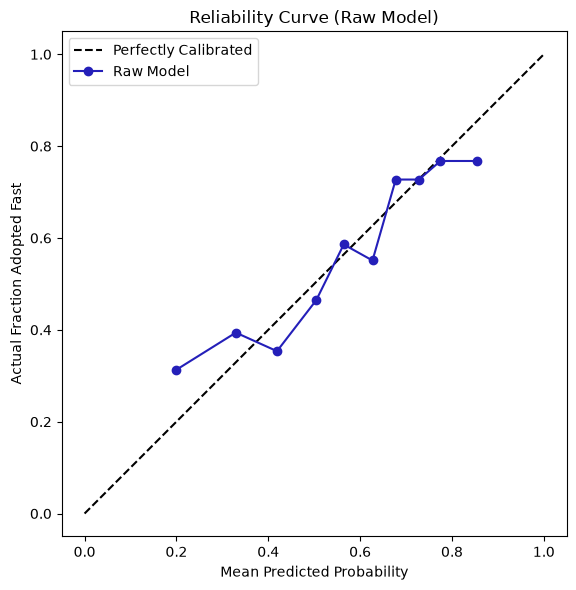

In [16]:
# 

proba_raw = final_clf.predict_proba(X_test)[:, 1]

brier_raw = brier_score_loss(y_test, proba_raw)
print(f"Raw Brier Score: {brier_raw:.4f}")

frac_pos, mean_pred = calibration_curve(y_test, proba_raw, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
ax.plot(mean_pred, frac_pos, "o-", label="Raw Model", color="#241FB9")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Actual Fraction Adopted Fast")
ax.set_title("Reliability Curve (Raw Model)")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

The output above shows that the model is not badly-miscalibrated, but the curve deviates from the perfect calibration line at the extreme ends. Therefore, calibration may be worth doing to find out whether it will improve the model or not.

In [17]:
# Calibrating the model

base = XGBClassifier(**{**model_mod.DEFAULT_PARAMS})
calibrated = CalibratedClassifierCV(base, method="isotonic", cv=5)
calibrated.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier...ree=None, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Optional[float]The initial 

Raw Brier:        0.2209
Calibrated Brier: 0.2211
Improvement:      -0.0002


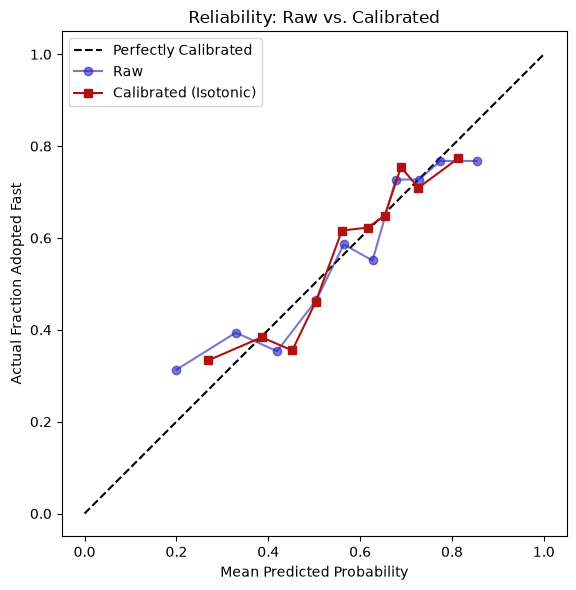

In [18]:
# Comparing the raw and calibrated models on the same test set

proba_cal = calibrated.predict_proba(X_test)[:, 1]
brier_cal = brier_score_loss(y_test, proba_cal)
print(f"Raw Brier:        {brier_raw:.4f}")
print(f"Calibrated Brier: {brier_cal:.4f}")
print(f"Improvement:      {brier_raw - brier_cal:+.4f}")

frac_cal, mean_cal = calibration_curve(y_test, proba_cal, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfectly Calibrated")
ax.plot(mean_pred, frac_pos, "o-", label="Raw", color="#241FB9", alpha=0.6)
ax.plot(mean_cal, frac_cal, "s-", label="Calibrated (Isotonic)", color="#B01212")
ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Actual Fraction Adopted Fast")
ax.set_title("Reliability: Raw vs. Calibrated")
ax.legend(); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

The calibration did not change the model's results meaningfully, and even slightly worsened the model. Therefore, the results of the raw model may be trustworthy and calibration is not needed after all.

In [22]:
# Building the explainer on the saved/final model and explaining the sample listing

explainer = explain_mod.build_explainer(final_clf)
print("Explainer Built:", type(explainer).__name__)

sample_feats = preprocess.preprocess(one_cat)
shap_values = explainer.shap_values(sample_feats)
print("SHAP Values Shape:", np.array(shap_values).shape)
print("Base Value:", explainer.expected_value)
print("\nRaw SHAP Values (log-odds) for this Cat:")
for feat, val in zip(sample_feats.columns, np.array(shap_values)[0]):
    print(f"  {feat:<18} {val:+.4f}")

Explainer Built: TreeExplainer
SHAP Values Shape: (1, 13)
Base Value: 0.26146704

Raw SHAP Values (log-odds) for this Cat:
  Breed1             -0.0540
  Color1             -0.0289
  Age                -0.8246
  MaturitySize       -0.0209
  FurLength          -0.0746
  Vaccinated         +0.0725
  Dewormed           -0.0185
  Sterilized         +0.0543
  Health             +0.0207
  Fee                +0.0788
  PhotoAmt           -0.0426
  desc_word_count    -0.3654
  is_free            +0.0229


The SHAP values appear as expected, and one thing to note is that age and more-notably description word count are the two most-impactful features, aligning with what was revealed during EDA.

In [23]:
# Testing whether the explainer produces the right contract

explainer = explain_mod.build_explainer(final_clf)
factors = explain_mod.explain_prediction(final_clf, explainer, sample_feats)

print("Ranked Factors (score-point impacts):")
for f in factors:
    print(f"  {f['impact']:+6.1f}  {f['label']:<22} = {str(f['value']):<10} [{f['direction']}]")

Ranked Factors (score-point impacts):
   -13.7  Age                    = 12         [negative]
    -6.1  Description length     = 6          [negative]
    +1.3  Adoption fee           = 0          [positive]
    -1.2  Fur length             = 1          [negative]
    +1.2  Vaccination status     = 1          [positive]
    -0.9  Breed                  = 243        [negative]
    +0.9  Sterilization status   = 2          [positive]
    -0.7  Number of photos       = 3          [negative]
    -0.5  Color                  = 1          [negative]
    +0.4  Free adoption          = 1          [positive]
    -0.3  Maturity size          = 2          [negative]
    -0.3  Deworming status       = 1          [negative]
    +0.3  Health status          = 1          [positive]


The output above will be the data that the improvement recommendation system receives and the app's UI displays, and it displays as designed.

In [24]:
# Testing the global importance module

importance = explain_mod.global_importance(explainer, X_test)

print("Global Feature Importance (mean |SHAP|):")
for f in importance:
    print(f"  {f['importance']:.4f}  {f['label']}")

Global Feature Importance (mean |SHAP|):
  0.5338  Age
  0.2364  Breed
  0.1698  Number of photos
  0.1407  Color
  0.1317  Description length
  0.0944  Adoption fee
  0.0712  Fur length
  0.0691  Sterilization status
  0.0543  Maturity size
  0.0425  Vaccination status
  0.0347  Deworming status
  0.0282  Health status
  0.0137  Free adoption


The top-5 most important features across all cats are their age, breed, number of photos, colour and description length of the listing, aligning with what has been observed in the EDA phase.